In [124]:
import numpy as np
from matplotlib import pyplot as plt

Vamos a definir la función para el **PAS**

In [125]:
def simular_PAS(p, n, reps=1):
  # Input:
  # p: Es la probabilidad que hay de tomar el 0 o el 1, es claro que su valor estará entre 0 y 1.
  # n: Es el numero de pasos que hay en la trayectoria.
  # reps: Es el numero de trayectorias independientes que hay a simular
  # Output: Es una matriz (resp x n) donde las filas son una trayectoria del PAS y  la columna el valor acumulado

    # 1. Generamos una matriz aleatoria
    # Usamos np.random.choice para elegir entre [1, -1] con las probabilidades dadas
    # Tambien podriamos haberla craeado con valores al azar y luego usar np.where(random_matrix < p, 1, -1)
    pasos = np.random.choice([1, -1], size=(reps, n), p=[p, 1-p])

    # 2. Calculamos la trayectoria acumulando los pasos
    trayectorias = np.cumsum(pasos, axis=1) # Shape: (reps, n)

    return trayectorias

Ahora veamos un ejemplo para ver el uso de la función:

In [126]:
n_pasos = 5
n_reps = 5
p = 0.5 # La probabilidad de ser 0 y 1 se reparte por igual

datos = simular_PAS(p, n_pasos, n_reps)

print(datos)

[[ 1  0  1  2  3]
 [ 1  0  1  0  1]
 [-1  0 -1  0  1]
 [-1 -2 -1  0 -1]
 [-1 -2 -1  0  1]]


Ahora veamos las graficas resultantes para ver las trayectorias dependiendo de la probabilidad.

**VISUALIZACIÓN 1: Gráfica 1,  p=0.5**

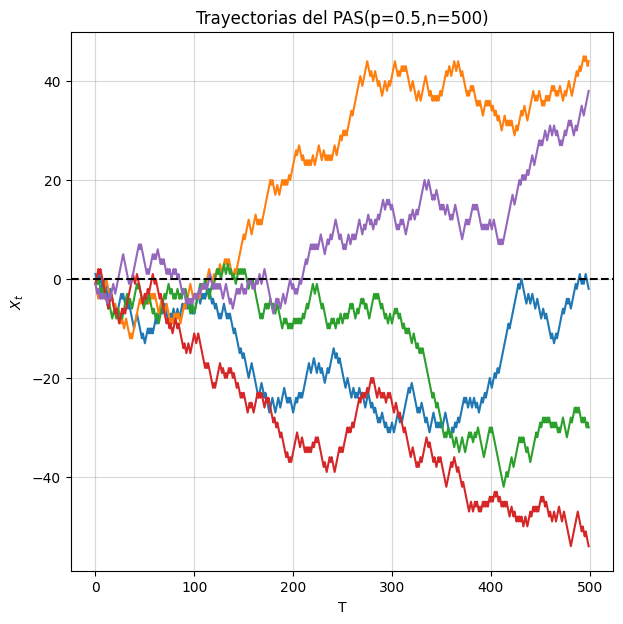

In [127]:
# Parámetros del experimento (diap 16)
p = 0.5
n = 500
reps = 5

# Utilizamos la funcion y simulamos.
trayectoria1 = simular_PAS(p, n, reps)

plt.figure(figsize=(7, 7)) # tamaño de la figura

plt.plot(trayectoria1.T)
# Con el .T trasponemos la matriz.
# Así de esta manera evitamos hacer un for

# Añadimos la línea horizontal en y=0
plt.axhline(0, color='black', linestyle='--')

# Añadimos titulos y etiquetas para cada eje
plt.title(f"Trayectorias del PAS(p={p},n={n})")
plt.xlabel("T")
plt.ylabel("$X_t$")

plt.grid(True, alpha=0.5) # Sirve para añadirle una cuadricula

# Mostramos el gráfico final
plt.show()

**Gráfica 2, p=0.6**

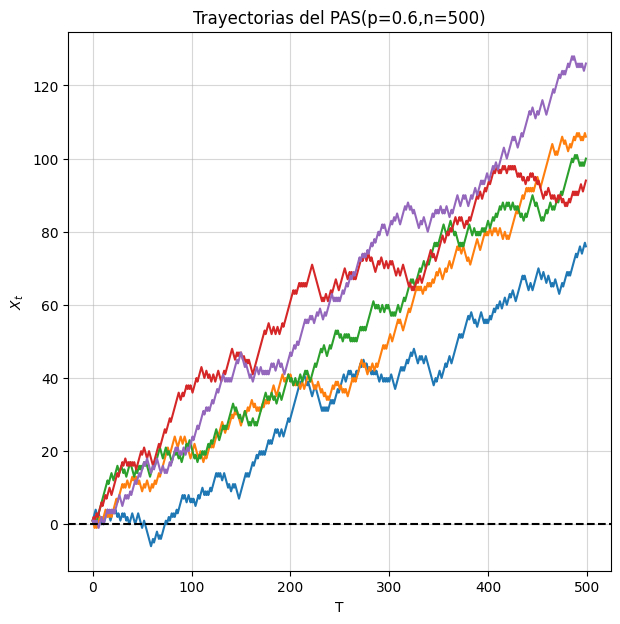

In [128]:
p = 0.6
n = 500
reps = 5

# Utilizamos la funcion y simulamos.
trayectoria2 = simular_PAS(p, n, reps)

# Simplemente tenemos que copiar y pegar arriba pues es el mismo codigo solo que cambiamos la probabilidad de
# ser 1 es decir de que ascienda pues ahora le damos mas probabilidad

plt.figure(figsize=(7, 7)) # tamaño de la figura

plt.plot(trayectoria2.T)
# Con el .T trasponemos la matriz.
# Así de esta manera evitamos hacer un for

# Añadimos la línea horizontal en y=0
plt.axhline(0, color='black', linestyle='--')

# Añadimos titulos y etiquetas para cada eje
plt.title(f"Trayectorias del PAS(p={p},n={n})")
plt.xlabel("T")
plt.ylabel("$X_t$")

plt.grid(True, alpha=0.5) # Sirve para añadirle una cuadricula

# Mostramos el gráfico final
plt.show()

**Gráfica 3, p=0.4**

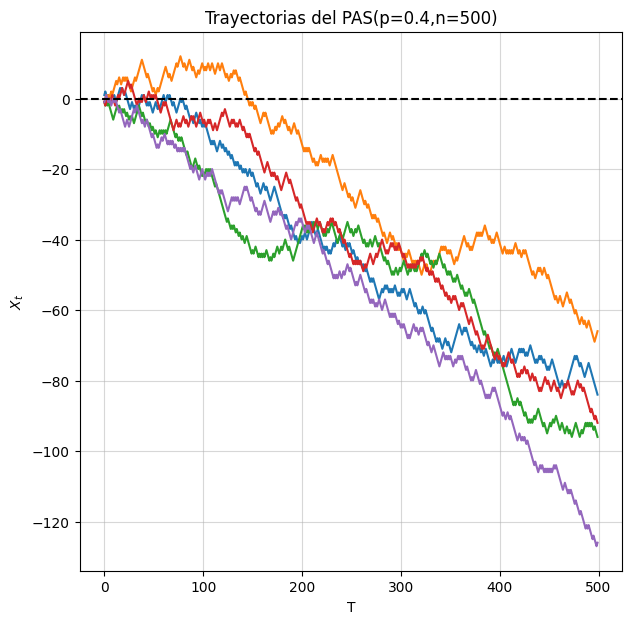

In [129]:
p = 0.4
n = 500
reps = 5

# Utilizamos la funcion y simulamos.
trayectoria3 = simular_PAS(p, n, reps)

# Simplemente tenemos que copiar y pegar arriba pues es el mismo codigo solo que cambiamos la probabilidad de
# ser 1 es decir de que descienda pues ahora le damos mas probabilidad

plt.figure(figsize=(7, 7)) # tamaño de la figura

plt.plot(trayectoria3.T)
# Con el .T trasponemos la matriz.
# Así de esta manera evitamos hacer un for

# Añadimos la línea horizontal en y=0
plt.axhline(0, color='black', linestyle='--')

# Añadimos titulos y etiquetas para cada eje
plt.title(f"Trayectorias del PAS(p={p},n={n})")
plt.xlabel("T")
plt.ylabel("$X_t$")

plt.grid(True, alpha=0.5) # Sirve para añadirle una cuadricula

# Mostramos el gráfico final
plt.show()

Ahora pasamos a hacer otras gráficas pues añadimos las **medias y desviaciónes típicas** luego procedemos a ver las trayectorias resultantes.

**VISUALUZACIÓN 2: Gráfica 1, p=0.5**

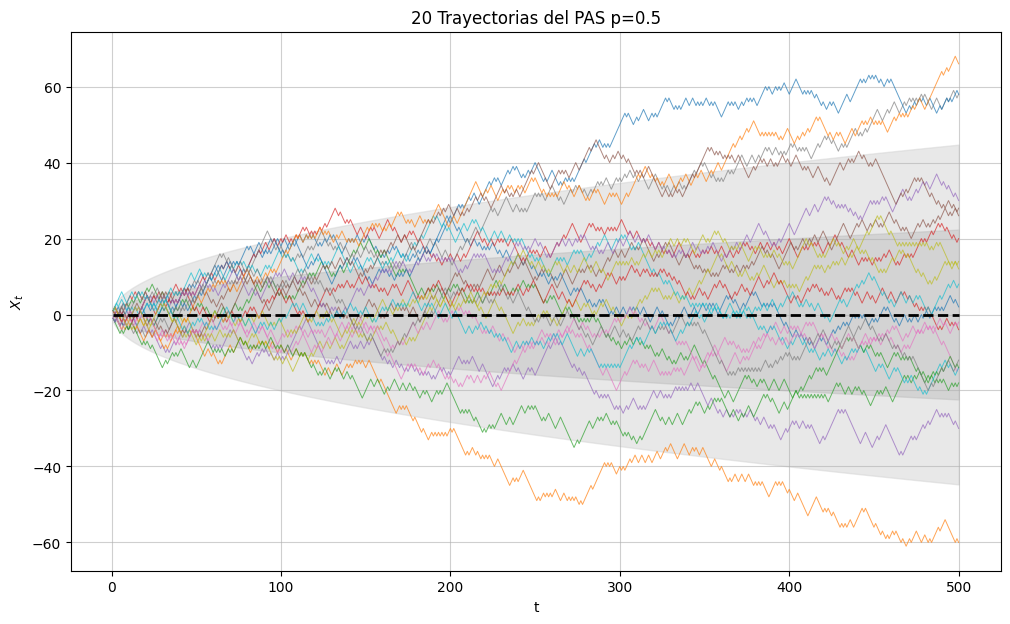

In [130]:
# Ponemos los parámetros
p = 0.5
n = 500
reps = 20

# Utilizamos la función
trayectoria1 = simular_PAS(p, n, reps)

t = np.arange(1,n+1) # Eje de tiempo (0, 1, ..., 500)
# Cálculo de Media y Desviación Típica Teóricas (p=0.5)
media_teorica = t * (2 * p - 1)
sigma_teorica = np.sqrt(t * 4 * p * (1 - p)) # La varianza de cada paso es 4p(1-p)

plt.figure(figsize=(12, 7))

# Pintamos el sombreado para ello usaremos plt.fill_between
# Amplitud +- 1 sigma (gris un poco más oscuro)
plt.fill_between(t, media_teorica - sigma_teorica, media_teorica + sigma_teorica,
                 color='darkgrey', alpha=0.5, label='$\\pm 1\\sigma$')

# Amplitud +-2 (gris claro)
plt.fill_between(t, media_teorica - 2 * sigma_teorica, media_teorica + 2 * sigma_teorica,
                 color='lightgrey', alpha=0.5, label='$\\pm 2\\sigma$')

# Pintamos las 20 trayectorias
plt.plot(t, trayectoria1.T, linewidth=0.7, alpha=0.7)

# Pintamos la media teórica (línea negra discontinua)
plt.plot(t, media_teorica, color='black', linestyle='--', linewidth=2, label='Media teórica')

#Añadimos titulo, etiquetas y cuadrícula
plt.title(f"20 Trayectorias del PAS p={p}")
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.grid(True, alpha=0.6)

plt.show()

**Gráfica 2, p=0.75**

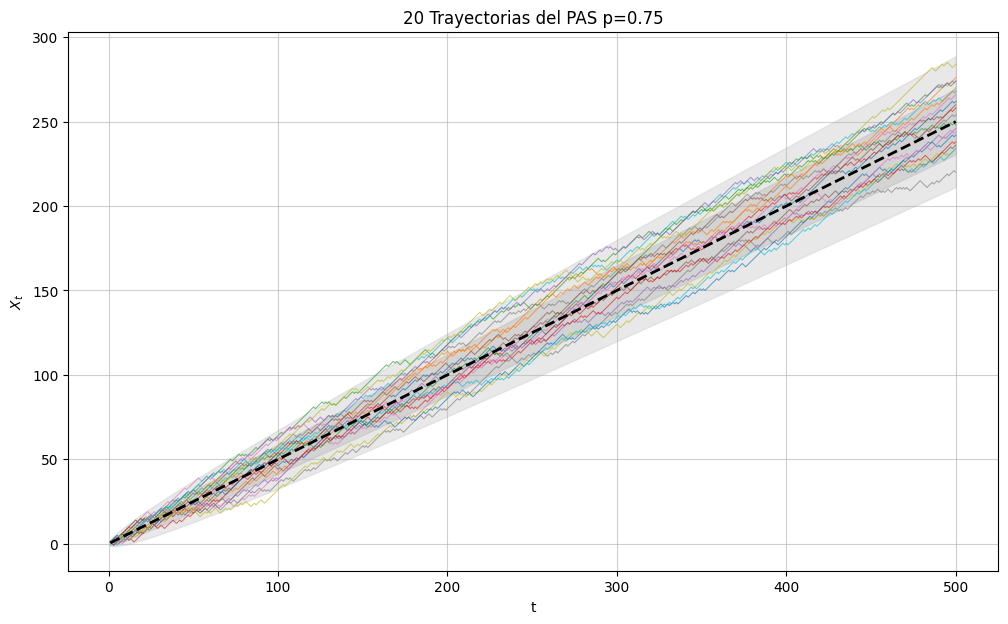

In [131]:
# Ponemos los parámetros
p = 0.75
n = 500
reps = 20

# Utilizamos la función
trayectoria2 = simular_PAS(p, n, reps)

t = np.arange(1,n+1) # Eje de tiempo (0, 1, ..., 500)
# Cálculo de Media y Desviación Típica Teóricas (p=0.5)
media_teorica = t * (2 * p - 1)
sigma_teorica = np.sqrt(t * 4 * p * (1 - p)) # La varianza de cada paso es 4p(1-p)

plt.figure(figsize=(12, 7))

# Pintamos el sombreado para ello usaremos plt.fill_between

# Amplitud +- 1 sigma (gris un poco más oscuro)
plt.fill_between(t, media_teorica - sigma_teorica, media_teorica + sigma_teorica,
                 color='darkgrey', alpha=0.5, label='$\\pm 1\\sigma$')

# Amplitud +-2 (gris claro)
plt.fill_between(t, media_teorica - 2 * sigma_teorica, media_teorica + 2 * sigma_teorica,
                 color='lightgrey', alpha=0.5, label='$\\pm 2\\sigma$')

# Pintamos las 20 trayectorias
plt.plot(t, trayectoria2.T, linewidth=0.7, alpha=0.7)

# Pintamos la media teórica (línea negra discontinua)
plt.plot(t, media_teorica, color='black', linestyle='--', linewidth=2, label='Media teórica')

#Añadimos titulo, etiquetas y cuadrícula
plt.title(f"20 Trayectorias del PAS p={p}")
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.grid(True, alpha=0.6)

plt.show()

**Gráfica 3, p=0.95**

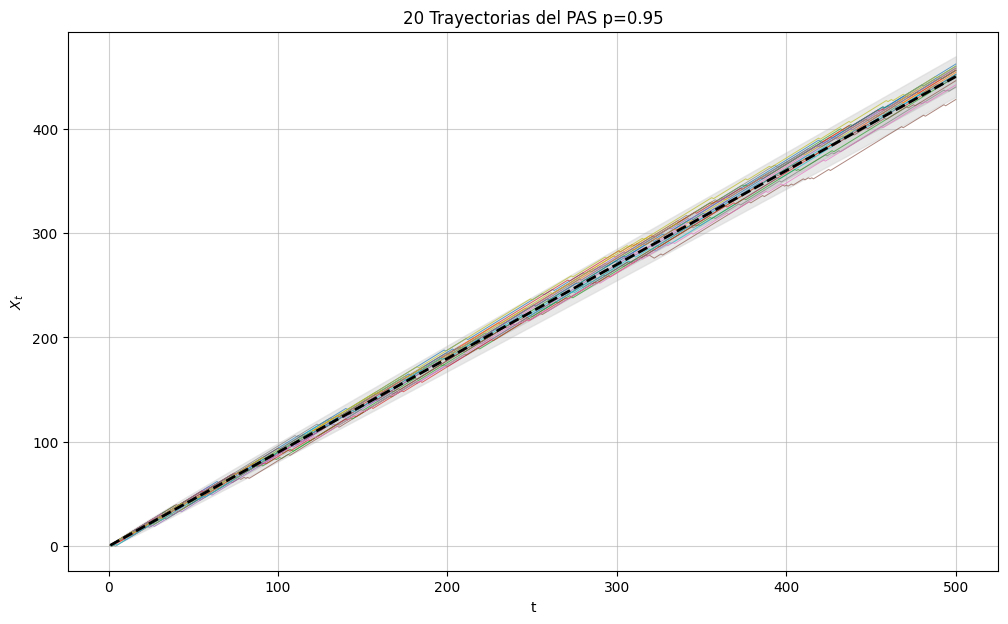

In [132]:
# Ponemos los parámetros
p = 0.95
n = 500
reps = 20

# Utilizamos la función
trayectoria3 = simular_PAS(p, n, reps)

t = np.arange(1,n+1) # Eje de tiempo (0, 1, ..., 500)
# Cálculo de Media y Desviación Típica Teóricas (p=0.5)
media_teorica = t * (2 * p - 1)
sigma_teorica = np.sqrt(t * 4 * p * (1 - p)) # La varianza de cada paso es 4p(1-p)

plt.figure(figsize=(12, 7))

# Pintamos el sombreado para ello usaremos plt.fill_between

# Amplitud +- 1 sigma (gris un poco más oscuro)
plt.fill_between(t, media_teorica - sigma_teorica, media_teorica + sigma_teorica,
                 color='darkgrey', alpha=0.5, label='$\\pm 1\\sigma$')

# Amplitud +-2 (gris claro)
plt.fill_between(t, media_teorica - 2 * sigma_teorica, media_teorica + 2 * sigma_teorica,
                 color='lightgrey', alpha=0.5, label='$\\pm 2\\sigma$')

# Pintamos las 20 trayectorias
plt.plot(t, trayectoria3.T, linewidth=0.7, alpha=0.7)

# Pintamos la media teórica (línea negra discontinua)
plt.plot(t, media_teorica, color='black', linestyle='--', linewidth=2, label='Media teórica')

#Añadimos titulo, etiquetas y cuadrícula
plt.title(f"20 Trayectorias del PAS p={p}")
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.grid(True, alpha=0.6)

plt.show()

**Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)**

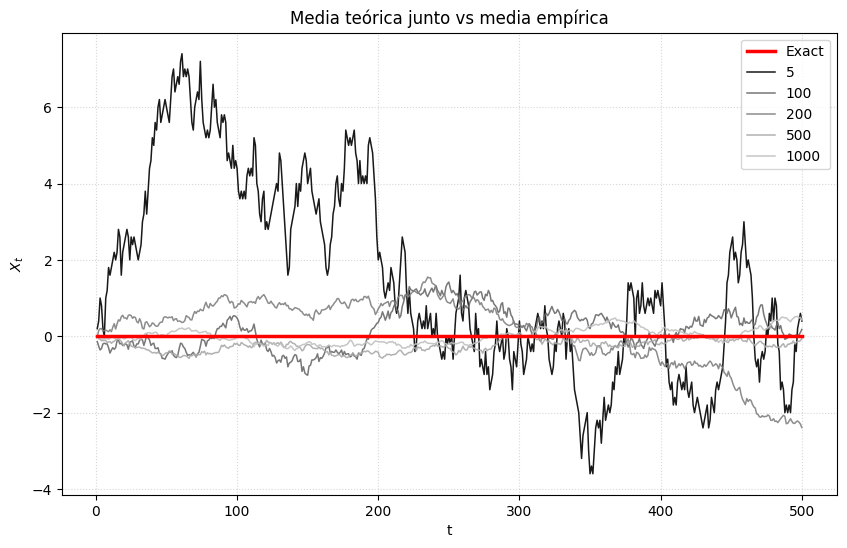

In [133]:
# Configuración de parametros
p = 0.5
n = 500

# Hacemos calculos de la media
t = np.arange(1,n + 1)
media_teorica = t * (2 * p - 1)

# Lista de repeticiones de la leyenda
lista_reps = [5, 100, 200, 500, 1000]
# Colores de negro a gris claro
colores = ['black', 'dimgray', 'gray', 'darkgray', 'silver']

# GENERAR EL GRÁFICO
plt.figure(figsize=(10, 6))

# Pintamos la media teórica (línea roja)
plt.plot(t, media_teorica, color='red', label='Exact', linewidth=2.5, zorder=10)

# Bucle para cada media empírica
for reps, col in zip(lista_reps, colores):
    # Generamos los datos
    trayectorias = simular_PAS(p, n, reps)

    # axis=0 hace la media vertical (promedia las 'reps' trayectorias en cada t)
    media_empirica = np.mean(trayectorias, axis=0)

    # Pintamos la línea resultante
    plt.plot(t, media_empirica, color=col, label=f'{reps}', linewidth=1.1, alpha=0.9)

# Ultimamos detalles
plt.title("Media teórica junto vs media empírica")
plt.xlabel("t")
plt.ylabel("$X_t$")
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()

plt.show()
